# Data Exploration

**Correlation Matrix and Behavior/Distribution of Selected Variables**

Author: Pete King

I want to get a better feel for how the variables relate to each other and which ones might present important features for predicting future volatility.  We can use a heatmap to visualize a correlation matrix for our data to quickly get a sense for which ones seem to be related.  We'll include the volatility for one of the ETFs as well to see how the input variables relate to one of our labels.

In [1]:
#123456789012345678901234567890123456789012345678901234567890123456789012345678
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import data_prep as dp

DATA_FOLDER = 'data/train-val-test/'
DATA_FILE = 'train_ALL_DATA.csv'
TICKER = 'SPY'

In [2]:
df = pd.read_csv(
    DATA_FOLDER + DATA_FILE,
    index_col='date',
    parse_dates=True
)

## II. Correlation Analysis

Here we display a correlation matrix as a heatmap using the seaborn plotting library for Python.  This makes it easy for us to quickly assess how our input variables relate to each other.  Whiter spots indicate strong positive correlation, while darker spots indicate strong negative correlation.  A middle-ground red color indicates weak or no correlation.

In [3]:
X_cols, y_cols = dp.get_X_y_cols(df, returns=True)
corr_matrix = df[
    [TICKER + '_vol_target'] + X_cols + [TICKER + '_ret_target']
    ].corr()

<Axes: >

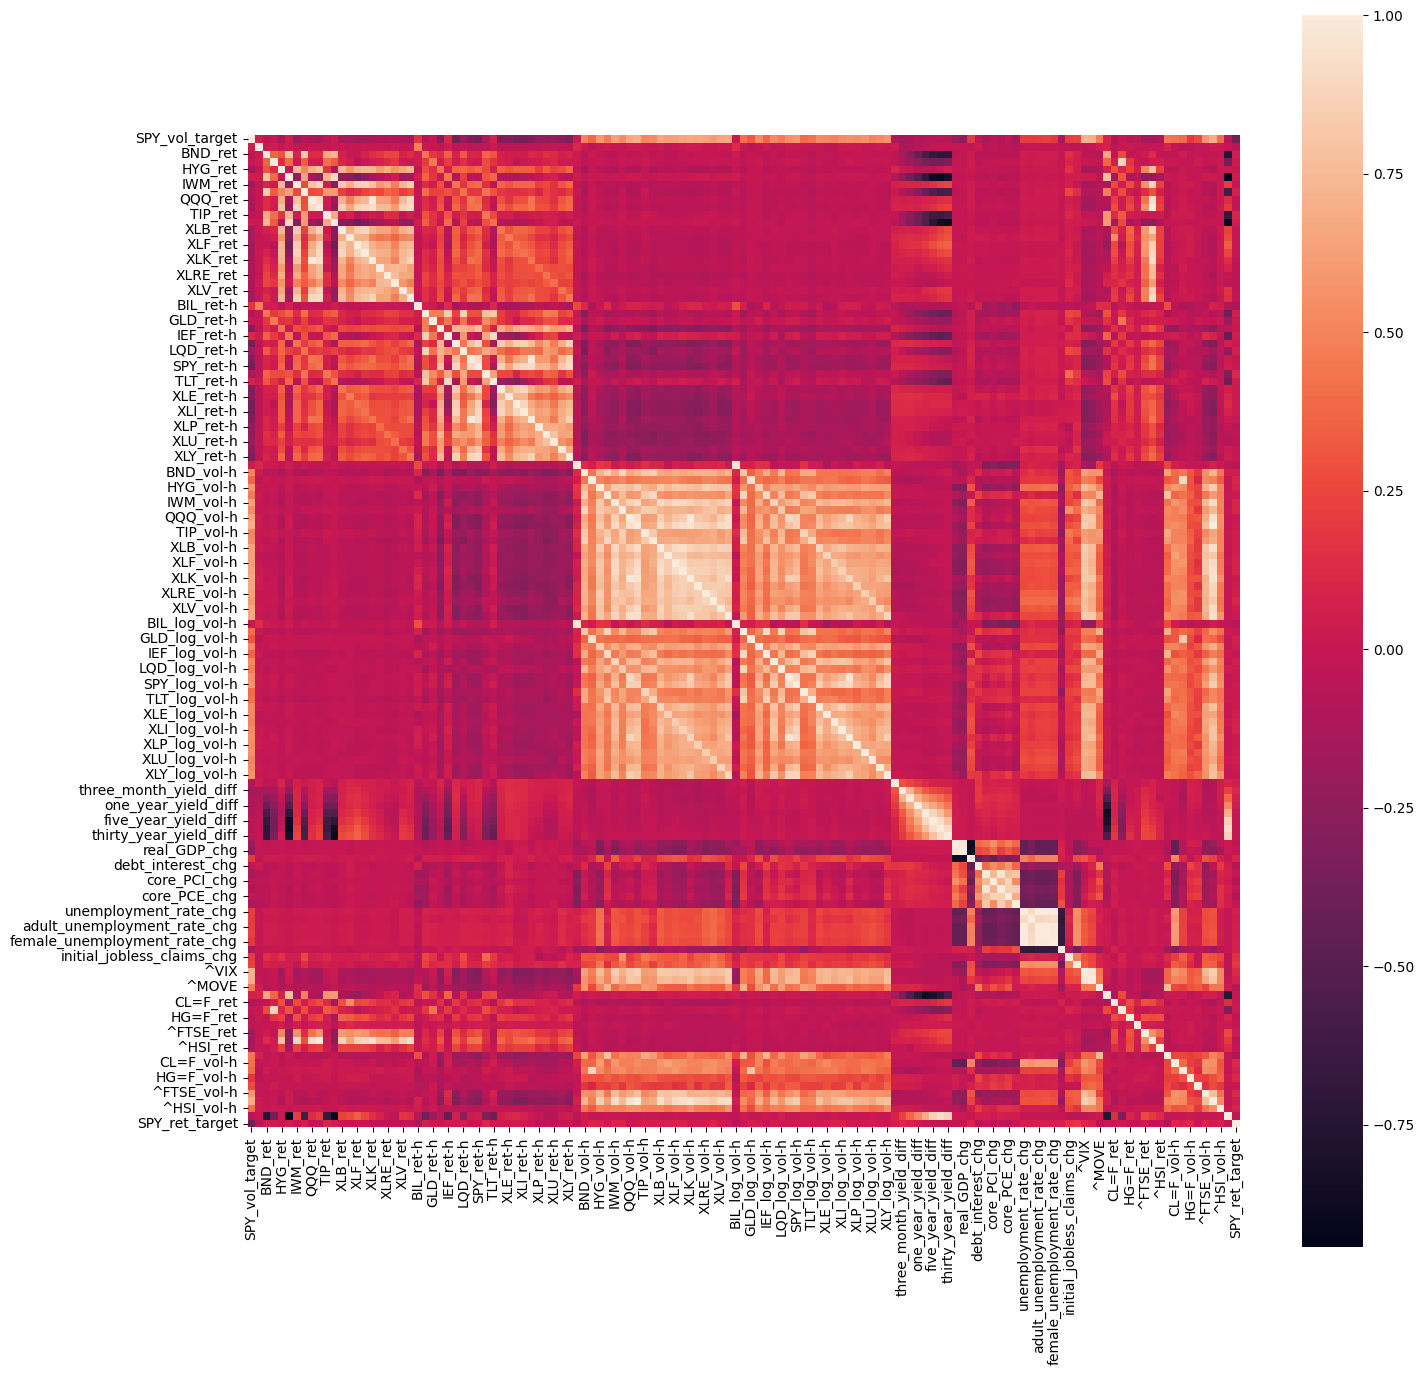

In [4]:
fig = plt.figure(figsize=(16, 16))
ax = fig.subplots()

sns.heatmap(corr_matrix, square=True, ax=ax)

The top line of pixels in this plot represents correlation with one of our target variables that we selected to focus on: future volatility for the S&P 500 ETF (SPY).

Right away we can see that recent historical volatility (for all assets) shows a strong positive correlation with future volatility for the target asset (SPY).  We also see that several market volatility indexes (^VIX, ^VXN, and ^MOVE) show strong positive correlation with SPY future volatility.  This makes intuitive sense: when investors are worried about the market, they 

We can also see that while daily returns appear generally uncorrelated with SPY future volatility, near-term historical returns show a fairly strong negative correlation.  This also makes sense: a negative trend in near-term returns is a stimulus to which investors react.  Bearish investors would see the losses as a reason to sell, while bullish investors would want to "buy the dip."  Overall, we see an increase in future market activity following a negative trend in near-term returns.

One final note: while near-term historical return over the last two weeks shows moderately strong negative correlation with future volatility, daily return appears to be generally uncorrelated with future volatility.  This may be due to the fact that investors tend to react to sustained trends in returns, rather than focusing on the daily fluctuations in an asset's price.

The input variables showing stronger correlation with our target variable will likely make the best features for our models.

### Correlation with future volatility

In [5]:
# Detailed examination of input variable correlation with future volatility
corr_vol = corr_matrix[TICKER + '_vol_target'].to_dict()
sorted([(k, v) for k, v in corr_vol.items()], key=lambda x:-np.abs(x[1]))

[('SPY_vol_target', 1.0),
 ('^VIX', 0.7221144531444739),
 ('SPY_vol-h', 0.6984860132429122),
 ('^VXN', 0.6982285191451217),
 ('^GSPC_vol-h', 0.6943994854654783),
 ('XLK_vol-h', 0.6685822790802558),
 ('QQQ_vol-h', 0.6627843947870186),
 ('XLY_vol-h', 0.6597047027189964),
 ('XLV_vol-h', 0.6575142042258414),
 ('XLP_vol-h', 0.6560062531993522),
 ('XLB_vol-h', 0.6453263002629176),
 ('XLI_vol-h', 0.6449810429286722),
 ('XLRE_vol-h', 0.6424495230577033),
 ('XLF_vol-h', 0.622770864065632),
 ('IWM_vol-h', 0.6216873840322675),
 ('XLE_vol-h', 0.6187745858381413),
 ('XLU_vol-h', 0.6028204854571486),
 ('^FTSE_vol-h', 0.5886876282523743),
 ('HYG_vol-h', 0.5852570449216054),
 ('SPY_log_vol-h', 0.578189762015878),
 ('XLY_log_vol-h', 0.5719238165424261),
 ('XLRE_log_vol-h', 0.5638189721786924),
 ('XLK_log_vol-h', 0.5590963934385447),
 ('QQQ_log_vol-h', 0.5517761043021101),
 ('XLP_log_vol-h', 0.5422995702104688),
 ('XLV_log_vol-h', 0.5356942670330815),
 ('XLI_log_vol-h', 0.5315859289452167),
 ('TLT_vol-h

**This analysis leads us to select the following features as the best predictors of future volatility:**
 - **Volatility indexes** (^VIX, ^VIXN, and to a slightly lesser degree ^MOVE)
 - **Recent historical volatility** of all assets/indexes for which we have daily price data (ETFs, commodity futures, and equity indexes)
 - **Recent historical returns** of all assets/indexes with daily price data
 - A few prominent **macroeconomic variables** (although most of these exhibit relatively low correlation):
    - change in real GDP, nominal GDP, and debt-to-GDP ratio
    - jobless claims and unemployment rates
    - the producer price index (although this has a late start date... if we drop it, we could look back further in time with the rest of our training data, which start earlier).

This analysis will inform either our feature selection and feature extraction via Principal Component Analysis (PCA).

### Correlation with future return

In [6]:
# Detailed examination of input variable correlation with future return
corr_ret = corr_matrix[TICKER + '_ret_target'].to_dict()
sorted([(k, v) for k, v in corr_ret.items()], key=lambda x:-np.abs(x[1]))

[('SPY_ret_target', 1.0),
 ('SPY_vol_target', -0.38790642685352283),
 ('continued_jobless_claims_chg', 0.1817755369308139),
 ('initial_jobless_claims_chg', 0.16222092131837054),
 ('BIL_ret-h', -0.12932923416471984),
 ('^VIX', 0.1157068399380378),
 ('TIP_ret-h', 0.1103720872004866),
 ('^FTSE_vol-h', 0.10986025214984667),
 ('SHY_vol-h', -0.10891300462997633),
 ('three_month_yield_diff', 0.10766326579427521),
 ('HG=F_vol-h', 0.10620643983048042),
 ('CL=F_vol-h', 0.10609635110146874),
 ('XLU_vol-h', 0.09784034973696552),
 ('GLD_vol-h', 0.09666249126695817),
 ('LQD_vol-h', 0.09608340981288249),
 ('TIP_ret', 0.09359542821819135),
 ('IWM_vol-h', 0.09120226340078788),
 ('debt_to_GDP_chg', 0.08999553734550515),
 ('core_PCI_chg', -0.08991759326592433),
 ('XLI_vol-h', 0.08833370695625378),
 ('HYG_vol-h', 0.08741546017279526),
 ('^MOVE', -0.08524834469191167),
 ('^HSI_vol-h', 0.08383938594760804),
 ('XLF_vol-h', 0.08254032253812243),
 ('XLI_log_vol-h', 0.08154338496325673),
 ('^VXN', 0.08069473770

We can see that most input variables unfortuantely show much weaker correlation with our target variable (future return for the S&P 500).  This is what we expected, as the literature generally indicates that returns are very difficult to predict.

It's worth noting that Robert F. Engle, who won the Nobel Prize in Economics in 2003 for his work in developing the AutoRegressive Conditional Heteroscedasticity (ARCH) model for volatility prediction, famously noted that *"Returns are almost unpredictable..."*

We'll do our best!  The input variables with strongest correlation appear to be the near-term historical volatility measures, mostly positive although occasionally negative.  Even so, these show overall weak correlation with future return.

## III. Exploring Strong vs. Weak Correlation

To get a sense of what we mean be 'moderately strong' vs. 'weak' correlation, lets examine a few important relationships.

### Forecasting volatility

We found several input features that show moderately strong correlation with a **future volatility** target.

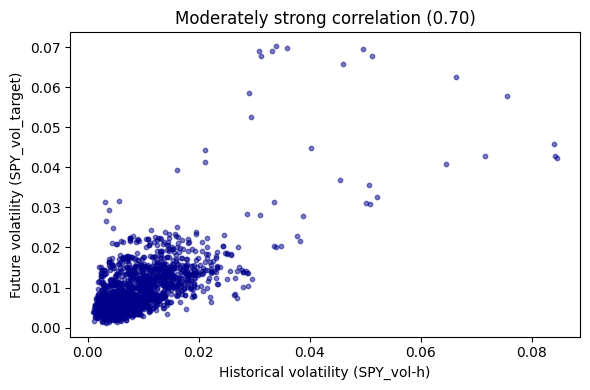

In [7]:
fig = plt.figure(figsize=(6, 4))
ax = fig.subplots()

x = TICKER + '_vol-h'
y = TICKER + '_vol_target'
ax.set_title(f'Moderately strong correlation ({corr_vol[x]:.2f})')
ax.set_xlabel('Historical volatility (' + x + ')')
ax.set_ylabel('Future volatility (' + y + ')')
ax.scatter(df[x], df[y], s=10, c='#00008B', alpha=0.5)
fig.tight_layout()

This actually looks like a situation where taking the log of the volatility values might result in a stronger correlation.  If so, we may want to go back and do some additional feature engineering!  =D

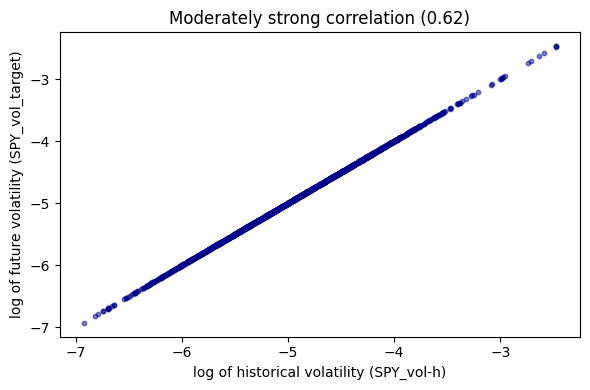

In [8]:
corr_log_ret = df[[x, y]].apply(np.log).corr().loc[x, y]
fig = plt.figure(figsize=(6, 4))
ax = fig.subplots()

ax.set_title(f'Moderately strong correlation ({corr_log_ret:.2f})')
ax.set_xlabel('log of historical volatility (' + x + ')')
ax.set_ylabel('log of future volatility (' + y + ')')
ax.scatter(
    df[x].apply(np.log), df[x].apply(np.log), s=10, c='#00008B', alpha=0.5
)
fig.tight_layout()

Just looking at the figure, it seems like the correlation value should be much higher for the log-transformed features -- I would think much closer to 1.

Regardless, I am very tempted to apply a log transformation to our historical and future volatility values to see if it helps the supervised models that assume a linear relationship between variables (Ridge, etc.).

### Forecasting return

We were unable to find input features that showed strong correlation with a **future return** target.  Historical volatility measures showed the strongest correlations with future return, but highest we saw was around 0.28.

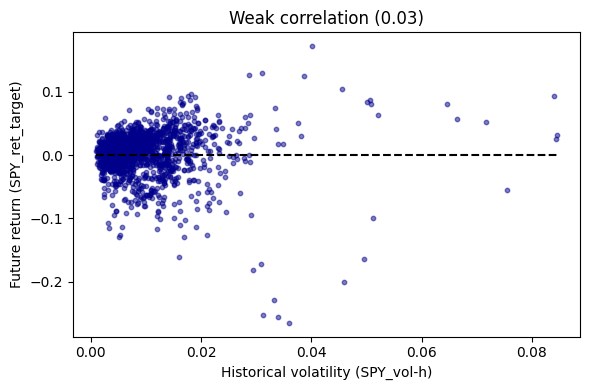

In [9]:
fig = plt.figure(figsize=(6, 4))
ax = fig.subplots()

x = TICKER + '_vol-h'
y = TICKER + '_ret_target'
ax.set_title(f'Weak correlation ({corr_ret[x]:.2f})')
ax.set_xlabel('Historical volatility (' + x + ')')
ax.set_ylabel('Future return (' + y + ')')
ax.hlines(0, df[x].min(), df[x].max(), colors='black', linestyles='dashed')
ax.scatter(df[x], df[y], s=10, c='#00008B', alpha=0.5)
fig.tight_layout()

Here we see that as historical volatility for an asset increases, future return can be positive or negative with almost equal likelihood.

Let's see if we can find a variable that shows a more consistent trend (either increasing or decreasing)... even if correlation values are low.

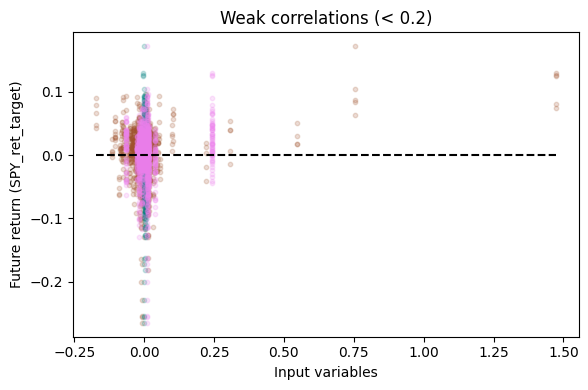

In [10]:
fig = plt.figure(figsize=(6, 4))
ax = fig.subplots()

x1 = 'continued_jobless_claims_chg'
x2 = 'core_PCE_chg'
x3 = 'debt_to_GDP_chg'
y = TICKER + '_ret_target'
ax.set_title(f'Weak correlations (< 0.2)')
ax.set_xlabel('Input variables')
ax.set_ylabel('Future return (' + y + ')')
ax.hlines(
    0,
    df[[x1, x2, x3]].values.flatten().min(),
    df[[x1, x2, x3]].values.flatten().max(),
    colors='black', linestyles='dashed'
    )
ax.scatter(df[x1], df[y], s=10, c='sienna', alpha=0.2, label=x1)
ax.scatter(df[x2], df[y], s=10, c='teal', alpha=0.2, label=x2)
ax.scatter(df[x3], df[y], s=10, c='violet', alpha=0.2, label=x3)
fig.tight_layout()

Overall, not a lot of luck in finding a variable that correlates well with future return, or even one that shows a consistent increasing or decreasing trend.  We may need to use more traditional financial techniques to forecast returns...  like guessing.